In [1]:
import os
os.chdir('/workspace/ed710142-55fa-4ea2-862b-a6043deee670')
print(os.listdir('.'))


['.prompts', '.kernel_llm_logs_1.txt', '.config', 'memory', 'ldh_def.py']


In [2]:
import subprocess
# Check parent workspace for r8 report or related material
for cmd in [
 "ls /workspace/",
 "find /workspace -maxdepth 4 -name '*r8*' 2>/dev/null",
 "find /workspace -maxdepth 4 -name '*omega*' 2>/dev/null",
 "find /workspace -maxdepth 4 -name '*moment*' 2>/dev/null",
]:
 print("$", cmd)
 print(subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout)
 print("---")


$ ls /workspace/
ed710142-55fa-4ea2-862b-a6043deee670
lost+found

---
$ find /workspace -maxdepth 4 -name '*r8*' 2>/dev/null

---
$ find /workspace -maxdepth 4 -name '*omega*' 2>/dev/null

---
$ find /workspace -maxdepth 4 -name '*moment*' 2>/dev/null

---


In [3]:
# Plan the analysis
print("""
ANALYSIS PLAN
=============
The 'report r8' ω-class decomposition engine does not exist in the workspace.
I will reconstruct the most natural ω-class decomposition of the Dirichlet
polynomial second moment, which is the canonical construction in analytic
number theory:

Definition:
 Given a Dirichlet polynomial S(t) = sum_{n=1..N} a_n n^{-1/2 - it},
 partition the support {1..N} by ω(n) = number of DISTINCT prime factors of n.
 Define S_k(t) = sum_{n: ω(n)=k} a_n n^{-1/2 - it}.
 Then S(t) = Σ_k S_k(t).

 By orthogonality of n^{-it} on long intervals,
 M_k := (1/T) ∫_0^T |S_k(t)|^2 dt → Σ_{ω(n)=k} |a_n|^2 / n as T→∞
 (the diagonal/off-diagonal cross-terms vanish on average).

 Therefore the DIAGONAL second moment is the Dirichlet series at s=1 of
 |a_n|^2 restricted by ω-class. We compute this exactly (no integration needed):
 M_k^diag = Σ_{n≤N, ω(n)=k} |a_n|^2 / n.

 Cross-class diagonals are zero (different n's), so Σ_k M_k = Σ_{n≤N} |a_n|^2 / n.

Coefficients a_n per L-function (on |s|=1 normalization, standard L=Σ a_n n^-s):
 ζ: a_n = 1
 L(Δ): a_n = τ(n) / n^{11/2} (normalized Ramanujan tau, so the L-function
 has functional equation symmetric about Re(s)=1/2).
 L_DH: a_n = A·χ(n) + B·χ̄(n) where χ is the order-4 char mod 5; |a_n|^2
 is well-defined.

I will compute |a_n|^2/n exactly with mpmath at dps=30 and partition by ω(n).

NOTE: The research objective mentions ∫|S_k|²dt over t∈[0,500] (a fixed
finite range). Because we are looking at the FRACTIONAL contributions, and
because the cross-class diagonals dominate on long ranges, fractional moments
on a fixed range t∈[0,500] for very large N are well-approximated by the
diagonal sums above (off-diagonal terms are O(N log N / T)). I'll therefore
report the diagonal fractional moments — exact, deterministic, and the 
correct asymptotic. I'll note this limitation explicitly.

For k = 1..4 and 'overflow' (ω≥5) for completeness.
""")



ANALYSIS PLAN
The 'report r8' ω-class decomposition engine does not exist in the workspace.
I will reconstruct the most natural ω-class decomposition of the Dirichlet
polynomial second moment, which is the canonical construction in analytic
number theory:

Definition:
 Given a Dirichlet polynomial S(t) = sum_{n=1..N} a_n n^{-1/2 - it},
 partition the support {1..N} by ω(n) = number of DISTINCT prime factors of n.
 Define S_k(t) = sum_{n: ω(n)=k} a_n n^{-1/2 - it}.
 Then S(t) = Σ_k S_k(t).

 By orthogonality of n^{-it} on long intervals,
 M_k := (1/T) ∫_0^T |S_k(t)|^2 dt → Σ_{ω(n)=k} |a_n|^2 / n as T→∞
 (the diagonal/off-diagonal cross-terms vanish on average).

 Therefore the DIAGONAL second moment is the Dirichlet series at s=1 of
 |a_n|^2 restricted by ω-class. We compute this exactly (no integration needed):
 M_k^diag = Σ_{n≤N, ω(n)=k} |a_n|^2 / n.

 Cross-class diagonals are zero (different n's), so Σ_k M_k = Σ_{n≤N} |a_n|^2 / n.

Coefficients a_n per L-function (on |s|=1 normaliz

In [4]:
# Check for cypari2 availability and other deps
try:
 import cypari2
 pari = cypari2.Pari()
 print("cypari2 OK; PARI version:", pari.version())
except Exception as e:
 print("cypari2 missing:", e)

import numpy as np, mpmath, sympy
print("numpy", np.__version__, "mpmath", mpmath.__version__, "sympy", sympy.__version__)


cypari2 missing: No module named 'cypari2'


numpy 2.4.3 mpmath 1.3.0 sympy 1.14.0


In [5]:
import subprocess
print(subprocess.run("pip install -q cypari2", shell=True, capture_output=True, text=True).stdout[-500:])
print(subprocess.run("pip install -q cypari2", shell=True, capture_output=True, text=True).stderr[-500:])


In [6]:
try:
 import cypari2
 pari = cypari2.Pari()
 print("cypari2 OK; PARI version:", pari.version())
except Exception as e:
 print("cypari2 still missing:", e)


cypari2 OK; PARI version: (2, 17, 2)


In [7]:
import numpy as np
from sympy import sieve, factorint
import math

# Build ω(n) array up to N_max using a linear sieve approach.
N_MAX = 100_000

def build_omega(N):
 # omega(n) = number of distinct prime factors. Use sieve.
 omega = np.zeros(N+1, dtype=np.int32)
 # smallest prime factor sieve
 spf = np.zeros(N+1, dtype=np.int64)
 for i in range(2, N+1):
 if spf[i] == 0:
 for j in range(i, N+1, i):
 if spf[j] == 0:
 spf[j] = i
 # walk n
 for n in range(2, N+1):
 m = n
 last_p = 0
 c = 0
 while m > 1:
 p = spf[m]
 if p != last_p:
 c += 1
 last_p = p
 m //= p
 omega[n] = c
 return omega

omega = build_omega(N_MAX)
print("omega(1..20):", omega[1:21])
# sanity: ω(12)=2 (2,3), ω(30)=3, ω(210)=4
print("ω(12)=", omega[12], "ω(30)=", omega[30], "ω(210)=", omega[210])


omega(1..20): [0 1 1 1 1 2 1 1 1 2 1 2 1 2 2 1 1 2 1 2]
ω(12)= 2 ω(30)= 3 ω(210)= 4


In [8]:
# Verify ω distribution at N=100000
unique, counts = np.unique(omega[1:N_MAX+1], return_counts=True)
print("ω distribution among n in [1, 100000]:")
for u, c in zip(unique, counts):
 print(f" ω={u}: {c}")


ω distribution among n in [1, 100000]:
 ω=0: 1
 ω=1: 9700
 ω=2: 33759
 ω=3: 38844
 ω=4: 15855
 ω=5: 1816
 ω=6: 25


In [9]:
# Build coefficients for the three L-functions.
# We use the "analytic normalization" so the functional equation is symmetric about Re(s)=1/2.
# For ζ: analytic = arithmetic; a_n = 1.
# For L(Δ): arithmetic a_n = τ(n); analytic a_n = τ(n)/n^{11/2}.
# For L_DH (Dirichlet character, weight 0): a_n = A·χ(n)+B·χ̄(n); already correct.

import cypari2
pari = cypari2.Pari()
pari.allocatemem(2**31)

# 1) ζ coefficients: trivial
import mpmath
mpmath.mp.dps = 40

# 2) L(Δ): tau(n) via PARI ramanujantau
# Pre-compute tau(n) for n in [1, N_MAX]
import time
t0 = time.time()
tau = np.zeros(N_MAX+1, dtype=object) # store as Python ints (can be very large)
# PARI's ramanujantau accepts a positive integer
# Vectorize via direct loop; PARI is fast
batch = 10000
for start in range(1, N_MAX+1, batch):
 end = min(start+batch-1, N_MAX)
 for n in range(start, end+1):
 tau[n] = int(pari.ramanujantau(n))
print(f"τ(n) computed for n=1..{N_MAX} in {time.time()-t0:.1f}s")
print("τ(1..10):", [int(tau[i]) for i in range(1, 11)])
# Sanity: τ(1)=1, τ(2)=-24, τ(3)=252, τ(4)=-1472, τ(5)=4830


PARI stack size set to 2147483648 bytes, maximum size set to 2147483648


τ(n) computed for n=1..100000 in 1.1s
τ(1..10): [1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]


In [10]:
# 3) L_DH coefficients: a_n = A·χ(n) + B·χ̄(n).
# Since χ is mod 5 of order 4 with χ(0)=0, χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1,
# and B=conj(A), we have a_n = 2·Re(A·χ(n)).
# |a_n|^2 = (A χ(n) + B χ̄(n))(Ā χ̄(n) + B̄ χ(n))
# = |A|^2 |χ(n)|^2 + |B|^2 |χ(n)|^2 + A·B̄ χ(n)^2 + Ā·B χ̄(n)^2
# But χ̄(n)=conj(χ(n)) since χ takes values in {0,±1,±i}. So |χ(n)|^2 = 1 if 5∤n else 0.
# |A|^2 = |B|^2 = (1+ξ²)/4.
# A·B̄ = (1-iξ)/2 · (1-iξ)/2 = (1-iξ)^2/4 (since B̄ = (1-iξ)/2)
# Wait: B = (1+iξ)/2, so B̄ = (1-iξ)/2 = A. So A B̄ = A^2.
# Actually A = (1-iξ)/2, so A^2 = (1-iξ)^2/4 = (1 - 2iξ - ξ²)/4
# And χ(n)^2 + χ̄(n)^2 = 2 Re(χ(n)^2).
# χ^2 values: χ(1)^2=1, χ(2)^2=i^2=-1, χ(3)^2=(-i)^2=-1, χ(4)^2=(-1)^2=1, χ(5)^2=0
# So χ(n)^2 = χ_2(n) where χ_2 is the real (quadratic, Legendre) character mod 5.
# Re(χ(n)^2) = χ_2(n) ∈ {0,±1}.
# A·B̄ χ(n)^2 + Ā·B χ̄(n)^2 = 2 Re(A^2 χ(n)^2) = 2 χ_2(n) · Re(A^2)/1 ... wait,
# = 2 Re(A^2) · χ_2(n) (since χ_2 is real)
# Re(A^2) = (1-ξ²)/4
# So |a_n|^2 = (1+ξ²)/2 · 𝟙[5∤n] + (1-ξ²)/2 · χ_2(n)
# where the second term is 0 if 5|n, else χ_2(n).
# Equivalently for 5∤n: |a_n|^2 = [(1+ξ²) + (1-ξ²)·χ_2(n)] / 2.
# χ_2 mod 5: χ_2(1)=1, χ_2(2)=-1, χ_2(3)=-1, χ_2(4)=1.

# Let's verify numerically
import mpmath
mpmath.mp.dps = 50
xi = (mpmath.sqrt(10 - 2*mpmath.sqrt(5)) - 2)/(mpmath.sqrt(5)-1)
I = mpmath.mpc(0,1)
A_dh = (1 - I*xi)/2
B_dh = (1 + I*xi)/2
chi_vals = {1: mpmath.mpc(1), 2: I, 3: -I, 4: mpmath.mpc(-1), 0: mpmath.mpc(0)}
def a_dh(n):
 r = n % 5
 return A_dh*chi_vals[r] + B_dh*mpmath.conj(chi_vals[r])

for n in [1,2,3,4,5,6,7,8,9,10,11]:
 val = a_dh(n)
 sq = (mpmath.fabs(val))**2
 print(f"n={n}: a_n = {val}, |a_n|^2 = {sq}")
print("\nξ^2:", xi**2)
print("(1+ξ²)/2 =", (1+xi**2)/2)
print("(1-ξ²)/2 =", (1-xi**2)/2)
print("So for χ_2(n)=+1 (n≡±1): |a|² = 1")
print("For χ_2(n)=-1 (n≡±2): |a|² = ξ²")
print("For 5|n: |a|² = 0")


n=1: a_n = (1.0 + 0.0j), |a_n|^2 = 1.0
n=2: a_n = (0.28407904384041229602829183239312616909108808844573 + 0.0j), |a_n|^2 = 0.080700903149282891268592516657456587427214072535939
n=3: a_n = (-0.28407904384041229602829183239312616909108808844573 + 0.0j), |a_n|^2 = 0.080700903149282891268592516657456587427214072535939
n=4: a_n = (-1.0 + 0.0j), |a_n|^2 = 1.0
n=5: a_n = (0.0 + 0.0j), |a_n|^2 = 0.0
n=6: a_n = (1.0 + 0.0j), |a_n|^2 = 1.0
n=7: a_n = (0.28407904384041229602829183239312616909108808844573 + 0.0j), |a_n|^2 = 0.080700903149282891268592516657456587427214072535939
n=8: a_n = (-0.28407904384041229602829183239312616909108808844573 + 0.0j), |a_n|^2 = 0.080700903149282891268592516657456587427214072535939
n=9: a_n = (-1.0 + 0.0j), |a_n|^2 = 1.0
n=10: a_n = (0.0 + 0.0j), |a_n|^2 = 0.0
n=11: a_n = (1.0 + 0.0j), |a_n|^2 = 1.0

ξ^2: 0.080700903149282891268592516657456587427214072535939
(1+ξ²)/2 = 0.54035045157464144563429625832872829371360703626797
(1-ξ²)/2 = 0.45964954842535855436570374167127

In [11]:
# Build |a_n|^2 arrays as mpmath/float arrays for each L-function.
# We use float64 for the partial sums since we're summing many terms; precision
# is plenty for fractional moments.

import mpmath
mpmath.mp.dps = 50

# ζ: |a_n|^2 = 1
abs2_zeta = np.ones(N_MAX+1, dtype=np.float64)
abs2_zeta[0] = 0.0

# L_DH: closed-form derived above
xi2 = float(xi**2) # ξ² ≈ 0.0807009
abs2_ldh = np.zeros(N_MAX+1, dtype=np.float64)
for n in range(1, N_MAX+1):
 r = n % 5
 if r == 1 or r == 4:
 abs2_ldh[n] = 1.0
 elif r == 2 or r == 3:
 abs2_ldh[n] = xi2
 else:
 abs2_ldh[n] = 0.0

# L(Δ): a_n = τ(n) / n^{11/2}, so |a_n|^2 = τ(n)^2 / n^{11}.
# τ(n) can be astronomically large but τ(n)^2/n^{11} is bounded (Deligne).
# Use mpmath for safety: compute |a_n|^2 in mpf, then store float64.
abs2_ldelta = np.zeros(N_MAX+1, dtype=np.float64)
mpmath.mp.dps = 60 # extra precision since τ(n)^2 grows like n^11 with bounded ratio
for n in range(1, N_MAX+1):
 tn = tau[n]
 if tn == 0:
 abs2_ldelta[n] = 0.0
 else:
 val = mpmath.mpf(tn)**2 / mpmath.mpf(n)**11
 abs2_ldelta[n] = float(val)
# Sanity: Deligne bound |τ(n)| ≤ d(n) n^{11/2} → |a_n|^2 ≤ d(n)^2
print("Max |a_n|^2 for L(Δ):", abs2_ldelta.max(), "at n=", abs2_ldelta.argmax())
print("First few values:", abs2_ldelta[1:11])
# Should equal τ(n)^2/n^11. n=1: 1. n=2: 576/2048 = 0.28125. n=3: 252²/3^11 = 63504/177147 ≈ 0.35850
print("Check n=2:", 24**2/2**11, "n=3:", 252**2/3**11)


Max |a_n|^2 for L(Δ): 14.967319599963202 at n= 82297
First few values: [1. 0.28125 0.35848194 0.51660156 0.47777587 0.10082305
 0.14178817 0.83084106 0.41154542 0.13437446]
Check n=2: 0.28125 n=3: 0.3584819387288523


In [12]:
# Compute diagonal moment fractions M_k / Σ_j M_j for ω-classes k = 1..4 (and ω≥5 lumped)
# at the three N_terms values, for each L-function.

N_LIST = [10_000, 50_000, 100_000]
K_LIST = [1, 2, 3, 4] # specifically requested k=1..4
# We'll also track ω=0 (n=1) and ω≥5 separately for completeness

def moment_table(abs2_arr, label):
 rows = []
 n_arr = np.arange(N_MAX+1)
 # |a_n|^2 / n, with n=1 corresponding to ω=0
 with np.errstate(divide='ignore', invalid='ignore'):
 contrib = np.where(n_arr>0, abs2_arr / np.maximum(n_arr,1), 0.0)
 # Precompute prefix structures by sorting nothing; we'll mask by N
 for N in N_LIST:
 mask = (n_arr >= 1) & (n_arr <= N)
 total = contrib[mask].sum()
 omega_arr = omega.copy()
 # Bin: k=0,1,2,3,4,>=5
 bins = {}
 for k in [0,1,2,3,4]:
 sel = mask & (omega_arr == k)
 bins[k] = contrib[sel].sum()
 sel_ge5 = mask & (omega_arr >= 5)
 bins['>=5'] = contrib[sel_ge5].sum()
 row = {'L': label, 'N': N, 'total': total}
 for k in [0,1,2,3,4]:
 row[f'M_{k}'] = bins[k]
 row[f'frac_{k}'] = bins[k] / total if total>0 else float('nan')
 row['M_>=5'] = bins['>=5']
 row['frac_>=5'] = bins['>=5'] / total if total>0 else float('nan')
 rows.append(row)
 return rows

import pandas as pd
all_rows = []
all_rows.extend(moment_table(abs2_zeta, 'zeta'))
all_rows.extend(moment_table(abs2_ldelta, 'L(Δ)'))
all_rows.extend(moment_table(abs2_ldh, 'L_DH'))
df = pd.DataFrame(all_rows)
pd.options.display.float_format = '{:.6f}'.format
print(df.to_string(index=False))


 L N total M_0 frac_0 M_1 frac_1 M_2 frac_2 M_3 frac_3 M_4 frac_4 M_>=5 frac_>=5
zeta 10000 9.787606 1.000000 0.102170 3.253654 0.332426 3.676108 0.375588 1.622509 0.165772 0.229941 0.023493 0.005394 0.000551
zeta 50000 11.397004 1.000000 0.087742 3.415483 0.299683 4.238008 0.371853 2.251965 0.197593 0.465316 0.040828 0.026232 0.002302
zeta 100000 12.090146 1.000000 0.082712 3.477855 0.287660 4.459389 0.368845 2.522299 0.208624 0.587795 0.048618 0.042809 0.003541
L(Δ) 10000 4.333406 1.000000 0.230765 1.951190 0.450267 1.148593 0.265055 0.222449 0.051333 0.011104 0.002562 0.000071 0.000016
L(Δ) 50000 4.952124 1.000000 0.201934 2.112019 0.426488 1.443277 0.291446 0.365995 0.073907 0.030303 0.006119 0.000529 0.000107
L(Δ) 100000 5.217902 1.000000 0.191648 2.174208 0.416682 1.564482 0.299830 0.435774 0.083515 0.042403 0.008126 0.001036 0.000199
L_DH 10000 4.602738 1.000000 0.217262 1.296921 0.281772 1.681599 0.365347 0.572762 0.124440 0.051144 0.011112 0.000312 0.000068
L_DH 50000 5.298466

In [13]:
# Important caveat to test: my diagonal-sum approach is the T→∞ limit.
# The problem asks for ∫_0^500 |S_k|^2 dt with fixed T=500. The off-diagonal
# (between different n in the same ω-class) cross terms decay like 1/T, so:
# M_k^{T=500} = T · diag_k + small off-diagonal correction.
# Fractional moments frac_k = M_k/ΣM_j therefore at fixed T match the diagonal
# fractions to leading order with relative correction ~ (log N)/T.
# Let's verify by directly computing ∫_0^500 |S_k|^2 dt for one small case (N=10^4)
# using the exact formula:
# ∫_0^T |Σ_n c_n n^{-it}|^2 dt
# = T Σ |c_n|^2 + Σ_{m≠n} c_m c̄_n · (n/m)^{iT} − 1) / (i log(n/m))... wait:
# ∫_0^T e^{i log(m/n) t} dt = (e^{i log(m/n) T} − 1) / (i log(m/n))
# c_n = a_n / sqrt(n), so |c_n|^2 = |a_n|^2/n. We're computing |S|^2 = sum_{m,n} c_m c̄_n e^{i log(m/n) t}.

# This is O(N^2) which is impractical for N=10^4. But we can verify on a smaller N=2000.
# For verifying that fractions are dominated by the diagonal sum, that's enough.

N_check = 2000
T_check = 500.0

def small_check(abs2_arr, omega_arr, K=[1,2,3,4]):
 # exact integral fractions
 # Coefficients c_n = sqrt(abs2_arr[n]/n) but |c_n|^2 = abs2_arr[n]/n which is all we need.
 # For S_k = sum_{ω(n)=k} c_n n^{-it}, |S_k|^2 = Σ_{m,n in class k} c_m c̄_n e^{i log(m/n) t}
 # We need ∫_0^T |S_k|^2 dt for k=1..4.
 # If a_n is real (true for ζ, L(Δ), L_DH all real-coefficient Dirichlet polys),
 # then c_n is real (we take positive sqrt with sign of a_n; actually c_n = a_n/sqrt(n)).
 # We need actual a_n (not |a_n|), because cross terms involve c_m c̄_n (real here).
 # For ζ: a_n = 1, c_n = 1/sqrt(n).
 # For L(Δ): a_n = τ(n)/n^{11/2}, c_n = τ(n)/n^{6}. (real, signed)
 # For L_DH: a_n = A·χ(n)+B·χ̄(n) — REAL! (since B=conj(A) and χ̄=conj(χ)). c_n = a_n/sqrt(n) real signed.
 # OK so we can do it as a real Hermitian quadratic form:
 # ∫_0^T |S_k|^2 dt = Σ_{m,n} c_m c_n · K(m,n; T)
 # where K(m,n;T) = ∫_0^T cos(log(m/n) t) dt (since c's are real and the imaginary parts cancel)
 # K(m,m;T) = T.
 # K(m,n;T) = sin(log(m/n) T) / log(m/n) for m≠n.
 pass # we'll implement below for one L-function as a sanity check

# Let's do the sanity for ζ at N=2000, T=500.
import numpy as np
N_sanity = 2000
T = 500.0
n_arr = np.arange(1, N_sanity+1)
# coefficient c_n = 1/sqrt(n)
c = 1.0/np.sqrt(n_arr.astype(np.float64))
log_n = np.log(n_arr.astype(np.float64))
# K(m,n) = sin(L*T)/L where L = log(m) - log(n), with K(m,m)=T
# Compute the moment fractions per ω class.
omega_local = omega[1:N_sanity+1].copy()

# To avoid full N^2: N=2000 → 4M ops, fine.
log_m, log_n2 = np.meshgrid(log_n, log_n, indexing='ij')
L = log_m - log_n2
# Compute K matrix
with np.errstate(invalid='ignore', divide='ignore'):
 K = np.where(np.abs(L) < 1e-15, T, np.sin(L*T)/np.where(np.abs(L)<1e-15, 1.0, L))
# c_m c_n K
M_full = (c[:,None]*c[None,:]*K)
# Diagonal-only integral per class:
moments_full = {}
moments_diag = {}
for k in [1,2,3,4]:
 mask = (omega_local == k)
 moments_full[k] = M_full[np.ix_(mask, mask)].sum()
 moments_diag[k] = (c[mask]**2).sum() * T

total_full = sum(moments_full[k] for k in [1,2,3,4])
total_diag = sum(moments_diag[k] for k in [1,2,3,4])

print("ζ, N=2000, T=500 — sanity check that diagonal frac ≈ exact-integral frac:")
print(f"{'k':>3} {'frac_diag':>12} {'frac_exact':>12} {'rel_diff':>10}")
for k in [1,2,3,4]:
 fd = moments_diag[k]/total_diag
 fe = moments_full[k]/total_full
 print(f"{k:>3} {fd:>12.6f} {fe:>12.6f} {abs(fd-fe)/fd:>10.2e}")


ζ, N=2000, T=500 — sanity check that diagonal frac ≈ exact-integral frac:
 k frac_diag frac_exact rel_diff
 1 0.425936 0.314004 2.63e-01
 2 0.422625 0.490495 1.61e-01
 3 0.140557 0.187222 3.32e-01
 4 0.010881 0.008279 2.39e-01


In [14]:
# Notable: at N=2000, T=500 the off-diagonal contribution is NOT negligible.
# This is because for many m,n pairs, log(m/n) can be tiny (close primes among large n's),
# making sin(LT)/L close to T. Specifically when |log(m/n)| · T ≪ 1, we get K≈T as well.
# So my diagonal-only assumption is WRONG at T=500. The actual integral matters.
#
# This is a critical finding: at moderate T, off-diagonal terms are sizable.
# The research-objective explicitly fixes T=500, so we MUST compute the full integral.
#
# For N up to 10^5, full N^2 = 10^10 pairs is infeasible. But we can be clever:
# |S(t)|^2 dt can be computed by sampling |S(t)|^2 on a dense grid then integrating
# (Simpson's rule). For N=10^5, evaluating S(t) at one t takes O(N) ≈ 10^5 ops;
# we need ~ O(T · N / (2π)) sample points to resolve oscillations of n^{-it} for
# largest n. For N=10^5 the highest frequency is log(N)/(2π) ≈ 1.83 cycles per
# unit t, so we need ≥ 4 samples per unit t (Nyquist + safety). Over [0, 500],
# that's 2000 samples × N=10^5 = 2×10^8 ops per L-function: feasible (vectorized in NumPy).
#
# Even better: |S_k(t)|^2 for k=1..4 separately requires only computing each S_k(t)
# once per t and then squaring. So we need 4 partial sums per t, each O(|class_k|).
#
# Plan:
# For each L-function:
# 1. Build a_n for n=1..N.
# 2. Form c_n = a_n / sqrt(n) and log_n = log(n) — pre-stored.
# 3. Choose Nyquist-safe sampling: Δt = 2π / (4 · log(N)) — ~0.86 for N=10^5.
# Use Δt = 0.1 to be safe (factor of 8 oversampling).
# 4. For each t in {0, Δt, 2Δt, ..., T}, compute S_k(t) = Σ_{ω(n)=k} c_n exp(-i t log n).
# 5. Integrate |S_k(t)|^2 over [0, T] by trapezoid/Simpson rule.
#
# N=10^5, Δt=0.1 → 5001 samples; total ops ≈ 5001 × 4 × 10^5 = 2×10^9. Too slow in plain Python loop
# but vectorized over n, OK. Memory: 10^5 complex per sample × 5001 = 5×10^9 — too big.
# Instead, vectorize over t in batches: e.g., 100 t-values at a time → 10^5 × 100 = 10^7 complex per batch
# = 160 MB. Feasible.
#
# Even better: use the closed-form K(m,n)=sin(L T)/L approach but only for pairs with |log(m/n)|·T < threshold.
# The number of such pairs is much smaller than N^2.
#
# Let me check: pairs with |log(m/n)| < 1/T = 0.002 → m/n in (e^{-0.002}, e^{0.002}) ≈ (0.998, 1.002).
# For each n, pairs m with m ∈ (0.998 n, 1.002 n) — about 0.004 n pairs.
# Total pairs: Σ 0.004 n ≈ 0.002 N² = 2×10^7 for N=10^5. Feasible!
# But pairs with |log(m/n)|·T < ~5 still contribute non-negligibly because sin(x)/x decays
# slowly. So we'd need threshold maybe |L|T < 50 → m/n in (e^{-0.1}, e^{0.1}). That's ~ 0.2 N² = 2×10^9. Bad.
#
# Better: directly compute S_k(t) by sampling. Let's implement vectorized sampling.

# First estimate the sampling rate properly.
# Highest "frequency" of n^{-it} = exp(-it log n) is log(N)/2π Hz. For N=10^5: log(10^5)≈11.5, /(2π)=1.83 Hz.
# Nyquist requires Δt < 1/(2·1.83) ≈ 0.273. Use Δt = 0.05 (factor of ~5 oversampling) for accurate
# integration of |S|^2 (which oscillates at twice the frequency, so we need Δt < 1/(4·1.83) = 0.137).
# Δt = 0.05 → 10001 samples × N=10^5 = 10^9 ops. Vectorized in chunks of 100 t's → 100 × 10^5 = 10^7 ops × 100 chunks. Maybe 30s.

# Actually we can do much better: use the FFT! S(t) = Σ c_n e^{-i t log n}. If t lives on a uniform grid,
# this is NOT a standard FFT because log n is not uniform. But we can split into a few chunks and use
# direct sum which is what we'll do.

# Let me first verify integration approach on the small N=2000 case
N_sanity = 2000
T = 500.0
DT = 0.05
ts = np.arange(0, T + DT/2, DT)
print(f"N_sanity={N_sanity}, T={T}, Δt={DT}, n_samples={len(ts)}")

n_arr = np.arange(1, N_sanity+1)
c = 1.0/np.sqrt(n_arr.astype(np.float64))
log_n = np.log(n_arr.astype(np.float64))
omega_local = omega[1:N_sanity+1]

# Compute S_k(t) for k=1..4 via direct sum, chunked over t
moments_int = {k: 0.0 for k in [1,2,3,4]}
moments_total_int = 0.0
masks = {k: (omega_local == k) for k in [1,2,3,4]}

batch_t = 200
import time
t0 = time.time()
# Accumulators for trapezoid integration
S_k_traces = {k: np.zeros(len(ts), dtype=np.complex128) for k in [1,2,3,4]}
for i in range(0, len(ts), batch_t):
 tb = ts[i:i+batch_t] # (B,)
 # E_{j,n} = exp(-i tb[j] log(n))
 phase = -np.outer(tb, log_n) # (B, N)
 E = np.exp(1j*phase) # (B, N) complex
 # Multiply by c
 Ec = E * c[None, :]
 for k in [1,2,3,4]:
 S_k_traces[k][i:i+batch_t] = Ec[:, masks[k]].sum(axis=1)
print(f"Sampling done in {time.time()-t0:.1f}s")

# Integrate |S_k|^2 via trapezoid
for k in [1,2,3,4]:
 mod2 = np.abs(S_k_traces[k])**2
 moments_int[k] = np.trapezoid(mod2, ts)

total_int = sum(moments_int.values())
print("Integration-based fractions vs exact-quadratic-form (from earlier):")
print(f"{'k':>3} {'frac_int':>12} {'frac_exact':>12} {'frac_diag':>12}")
for k in [1,2,3,4]:
 fi = moments_int[k]/total_int
 fe = M_full[np.ix_(omega_local==k, omega_local==k)].sum() / sum(M_full[np.ix_(omega_local==kk, omega_local==kk)].sum() for kk in [1,2,3,4])
 fd_arr = (c[omega_local==k]**2).sum()
 print(f"{k:>3} {fi:>12.6f} {fe:>12.6f}")


N_sanity=2000, T=500.0, Δt=0.05, n_samples=10001


Sampling done in 0.7s
Integration-based fractions vs exact-quadratic-form (from earlier):
 k frac_int frac_exact frac_diag
 1 0.314004 0.314004
 2 0.490495 0.490495
 3 0.187222 0.187222
 4 0.008279 0.008279


In [15]:
# Perfect agreement to printed precision. Sampling approach is correct.
# Now scale up. For N=10^5 the matmul exp(1j * outer(tb, log_n)) for batch B=200 needs
# B*N = 2×10^7 complex evals = 160 MB. Memory OK. Total time: ~50 batches per L-function:
# For ζ at N=10^5: ~50 × 0.5s ≈ 25s, manageable.
# But we have 3 L-functions × 3 N values × 4 ω-classes. We can be clever: only need ONE
# sampling of full S(t) decomposed per class. So for each (L, N): one pass.

# Memory: 10001 × 200 batch sampling + 10^5 c, log_n arrays: fine.

# Let me estimate timing for N=10^5 more carefully.
import time
N_check = 100_000
n_arr_full = np.arange(1, N_check+1)
log_n_full = np.log(n_arr_full.astype(np.float64))
c_test = 1.0/np.sqrt(n_arr_full.astype(np.float64))

tb_test = np.arange(0, 50, 0.05) # 1000 points
t0 = time.time()
phase = -np.outer(tb_test, log_n_full)
E = np.exp(1j*phase)
print(f"exp computation for 1000×10^5: {time.time()-t0:.1f}s, shape={E.shape}, mem={E.nbytes/1e6:.0f}MB")
del E, phase


exp computation for 1000×10^5: 4.5s, shape=(1000, 100000), mem=1600MB


In [16]:
# 4.5s per 1000 t-samples × 100000 = 10^8 evals. Need 10001 samples total over [0,500].
# Estimate: 4.5s × 10 = 45s per (L, N=10^5). 3 L-funcs × 1 large N = ~2.5 min. Good.
# Plus N=5×10^4 (~25s ea) and N=10^4 (~5s ea).
# Total wall time should be ~5 min. Acceptable.

# However: I realized the *fractions* should be relatively stable w.r.t. the
# off-diagonal contribution because for large T, off-diagonal dominantly contributes
# to terms with small |log(m/n)| which mostly fall WITHIN the same ω-class
# (since changes in n by ±1 or small amounts don't change ω strongly... actually
# they can change ω drastically: n=p prime → ω=1, n=p+1 = even × ... → ω could be 2,3.
# So cross-class contributions are real).
# Let's just compute it properly.

# Now let me also reduce N_max to avoid recomputing omega for the full range —
# omega already covers up to 100000.

def compute_moments(abs2_arr_real_signed_c, omega_arr, N, T=500.0, DT=0.05, batch_t=200, verbose=False):
 """
 abs2_arr_real_signed_c: array such that c_n = signed_c_arr[n] (signed real coefficient).
 Returns: dict mapping omega class k=1..4 to M_k = ∫_0^T |S_k|^2 dt, plus k=0, '>=5', and total.
 """
 n_arr = np.arange(1, N+1)
 log_n = np.log(n_arr.astype(np.float64))
 c = abs2_arr_real_signed_c[1:N+1].astype(np.float64)
 omega_loc = omega_arr[1:N+1]
 ts = np.arange(0.0, T + DT/2, DT)
 masks = {k: (omega_loc == k) for k in [0,1,2,3,4]}
 masks['>=5'] = (omega_loc >= 5)
 keys = [0,1,2,3,4,'>=5']
 S_k = {k: np.zeros(len(ts), dtype=np.complex128) for k in keys}
 for i in range(0, len(ts), batch_t):
 tb = ts[i:i+batch_t]
 phase = -np.outer(tb, log_n) # (B, N)
 np.exp(1j*phase, out=phase.astype(np.complex128)) # in-place not possible due to dtype; rewrite
 # actually just create
 E = np.exp(1j*phase)
 Ec = E * c[None, :]
 for k in keys:
 if masks[k].any():
 S_k[k][i:i+batch_t] = Ec[:, masks[k]].sum(axis=1)
 del E, Ec, phase
 moments = {k: float(np.trapezoid(np.abs(S_k[k])**2, ts)) for k in keys}
 moments['total'] = sum(moments[k] for k in keys)
 moments['_ts'] = ts
 return moments

# Build signed coefficient arrays c_n (with sign), so c_n^2 = a_n^2 / n
# ζ: c_n = 1/sqrt(n)
c_zeta_full = np.zeros(N_MAX+1, dtype=np.float64)
c_zeta_full[1:] = 1.0/np.sqrt(np.arange(1, N_MAX+1, dtype=np.float64))

# L(Δ): c_n = τ(n) / n^{11/2} / sqrt(n) = τ(n) / n^6 (real signed)
c_ldelta_full = np.zeros(N_MAX+1, dtype=np.float64)
mpmath.mp.dps = 60
for n in range(1, N_MAX+1):
 tn = tau[n]
 c_ldelta_full[n] = float(mpmath.mpf(tn) / mpmath.mpf(n)**6)
print("L(Δ) c_n[1..10]:", c_ldelta_full[1:11])

# L_DH: c_n = a_n / sqrt(n) where a_n is REAL (derived above).
# a_n: r=1→1, r=2→ξ, r=3→-ξ, r=4→-1, r=0→0
c_ldh_full = np.zeros(N_MAX+1, dtype=np.float64)
xi_f = float(xi)
for n in range(1, N_MAX+1):
 r = n % 5
 if r == 1:
 a = 1.0
 elif r == 2:
 a = xi_f
 elif r == 3:
 a = -xi_f
 elif r == 4:
 a = -1.0
 else:
 a = 0.0
 c_ldh_full[n] = a / math.sqrt(n)
print("L_DH c_n[1..10]:", c_ldh_full[1:11])

# Verify diagonal sums match earlier fractional moments calculation:
for label, c in [('zeta', c_zeta_full), ('L(Δ)', c_ldelta_full), ('L_DH', c_ldh_full)]:
 diag = (c**2).sum()
 print(f" {label}: Σ c_n^2 over n=1..N_MAX = {diag:.6f}")


L(Δ) c_n[1..10]: [ 1. -0.375 0.34567901 -0.359375 0.30912 -0.12962963
 -0.14232165 0.32226562 -0.21383935 -0.11592 ]
L_DH c_n[1..10]: [ 1. 0.20087422 -0.16401311 -0.5 0. 0.40824829
 0.10737179 -0.10043711 -0.33333333 0. ]
 zeta: Σ c_n^2 over n=1..N_MAX = 12.090146
 L(Δ): Σ c_n^2 over n=1..N_MAX = 5.217902
 L_DH: Σ c_n^2 over n=1..N_MAX = 5.598100


In [17]:
# Diagonal sums match earlier values. Good.
# Now run the full integration for all 9 (L, N) combinations.

results = {} # results[label][N] = moments dict
labels_coeffs = [('zeta', c_zeta_full), ('L(Δ)', c_ldelta_full), ('L_DH', c_ldh_full)]

import time
for label, c_arr in labels_coeffs:
 results[label] = {}
 for N in N_LIST:
 t0 = time.time()
 # Use smaller batch for larger N to fit memory
 batch_t = 200 if N <= 50000 else 100
 m = compute_moments(c_arr, omega, N, T=500.0, DT=0.05, batch_t=batch_t)
 elapsed = time.time() - t0
 print(f"{label} N={N}: total M = {m['total']:.4f}, elapsed {elapsed:.1f}s")
 # Remove _ts for storage
 m.pop('_ts', None)
 results[label][N] = m


zeta N=10000: total M = 14049.6104, elapsed 7.0s


zeta N=50000: total M = 52555.7766, elapsed 33.4s


zeta N=100000: total M = 98775.2329, elapsed 66.7s


L(Δ) N=10000: total M = 2161.0199, elapsed 6.9s


L(Δ) N=50000: total M = 2348.2228, elapsed 33.3s


L(Δ) N=100000: total M = 2428.1712, elapsed 66.9s


L_DH N=10000: total M = 2025.6899, elapsed 6.9s


L_DH N=50000: total M = 2186.0524, elapsed 33.3s


L_DH N=100000: total M = 2238.8884, elapsed 66.9s


In [18]:
# Build summary table of fractions
import pandas as pd
rows = []
for label in ['zeta','L(Δ)','L_DH']:
 for N in N_LIST:
 m = results[label][N]
 tot = m['total']
 row = {'L': label, 'N': N, 'M_total': tot}
 for k in [0,1,2,3,4,'>=5']:
 row[f'M_{k}'] = m[k]
 row[f'frac_{k}'] = m[k]/tot
 rows.append(row)
df = pd.DataFrame(rows)
pd.options.display.float_format = '{:.6f}'.format
cols_show = ['L','N','M_total'] + [f'frac_{k}' for k in [0,1,2,3,4,'>=5']]
print(df[cols_show].to_string(index=False))


 L N M_total frac_0 frac_1 frac_2 frac_3 frac_4 frac_>=5
zeta 10000 14049.610398 0.035588 0.139915 0.461475 0.338769 0.024052 0.000202
zeta 50000 52555.776641 0.009514 0.061046 0.407457 0.458491 0.062826 0.000667
zeta 100000 98775.232940 0.005062 0.045356 0.378481 0.486073 0.083702 0.001326
L(Δ) 10000 2161.019922 0.231372 0.451779 0.262002 0.052480 0.002350 0.000017
L(Δ) 50000 2348.222814 0.212927 0.439947 0.273138 0.067750 0.006138 0.000100
L(Δ) 100000 2428.171224 0.205916 0.432779 0.278650 0.074669 0.007801 0.000185
L_DH 10000 2025.689869 0.246829 0.305318 0.354333 0.083217 0.010227 0.000076
L_DH 50000 2186.052439 0.228723 0.292338 0.358640 0.103679 0.015984 0.000635
L_DH 100000 2238.888403 0.223325 0.288004 0.357717 0.110130 0.019831 0.000993


In [19]:
# Observation: For ζ, fractions are NOT converging — frac_0 and frac_1 are dropping
# while frac_3 and frac_4 are rising. This is because ζ's coefficients are all 1, so
# the diagonal contribution Σ |a_n|^2/n = harmonic sum, which DIVERGES like log N.
# The fraction of mass in ω=k class therefore tracks the ω=k frequencies, which shift
# with N (Erdős–Kac: ω(n) ~ log log n with std sqrt(log log n)).
#
# Same trend qualitatively in L(Δ) and L_DH but slower because their |a_n|^2 averages
# are bounded (Rankin-Selberg).
#
# This suggests the fractions DO NOT converge for ζ (the support of ω(n)/loglog n drifts).
# For L(Δ), the moments Σ |τ(n)|^2/n^{12} converges as a sum so the SUMS stabilize.
# Let me verify by extrapolating: M_k values for L(Δ) should level off.
#
# Print the fractions side by side for stability analysis:
print("=== fraction stability across N for each L-function ===\n")
for label in ['zeta','L(Δ)','L_DH']:
 print(f"--- {label} ---")
 print(f"{'k':>4} | " + " | ".join(f"N={N:>6d}" for N in N_LIST))
 for k in [0,1,2,3,4,'>=5']:
 vals = [results[label][N][k]/results[label][N]['total'] for N in N_LIST]
 print(f"{str(k):>4} | " + " | ".join(f"{v:8.5f}" for v in vals))
 # Also print absolute moments
 print(f"{'TOT':>4} | " + " | ".join(f"{results[label][N]['total']:8.2f}" for N in N_LIST))
 print()


=== fraction stability across N for each L-function ===

--- zeta ---
 k | N= 10000 | N= 50000 | N=100000
 0 | 0.03559 | 0.00951 | 0.00506
 1 | 0.13991 | 0.06105 | 0.04536
 2 | 0.46147 | 0.40746 | 0.37848
 3 | 0.33877 | 0.45849 | 0.48607
 4 | 0.02405 | 0.06283 | 0.08370
 >=5 | 0.00020 | 0.00067 | 0.00133
 TOT | 14049.61 | 52555.78 | 98775.23

--- L(Δ) ---
 k | N= 10000 | N= 50000 | N=100000
 0 | 0.23137 | 0.21293 | 0.20592
 1 | 0.45178 | 0.43995 | 0.43278
 2 | 0.26200 | 0.27314 | 0.27865
 3 | 0.05248 | 0.06775 | 0.07467
 4 | 0.00235 | 0.00614 | 0.00780
 >=5 | 0.00002 | 0.00010 | 0.00019
 TOT | 2161.02 | 2348.22 | 2428.17

--- L_DH ---
 k | N= 10000 | N= 50000 | N=100000
 0 | 0.24683 | 0.22872 | 0.22333
 1 | 0.30532 | 0.29234 | 0.28800
 2 | 0.35433 | 0.35864 | 0.35772
 3 | 0.08322 | 0.10368 | 0.11013
 4 | 0.01023 | 0.01598 | 0.01983
 >=5 | 0.00008 | 0.00064 | 0.00099
 TOT | 2025.69 | 2186.05 | 2238.89



In [20]:
# Compute relative shifts between consecutive N values to quantify convergence.
import numpy as np
print("Relative change in fraction between consecutive N values (i.e., |Δfrac|/frac):\n")
for label in ['zeta','L(Δ)','L_DH']:
 print(f"--- {label} ---")
 print(f"{'k':>4} | f@10^4 f@5e4 f@10^5 | Δ(10^4→5e4) Δ(5e4→10^5)")
 for k in [0,1,2,3,4,'>=5']:
 vals = [results[label][N][k]/results[label][N]['total'] for N in N_LIST]
 d1 = (vals[1]-vals[0])/vals[0] if vals[0]>0 else float('nan')
 d2 = (vals[2]-vals[1])/vals[1] if vals[1]>0 else float('nan')
 print(f"{str(k):>4} | {vals[0]:.4f} {vals[1]:.4f} {vals[2]:.4f} | {d1:+.4f} {d2:+.4f}")
 print()


Relative change in fraction between consecutive N values (i.e., |Δfrac|/frac):

--- zeta ---
 k | f@10^4 f@5e4 f@10^5 | Δ(10^4→5e4) Δ(5e4→10^5)
 0 | 0.0356 0.0095 0.0051 | -0.7327 -0.4679
 1 | 0.1399 0.0610 0.0454 | -0.5637 -0.2570
 2 | 0.4615 0.4075 0.3785 | -0.1171 -0.0711
 3 | 0.3388 0.4585 0.4861 | +0.3534 +0.0602
 4 | 0.0241 0.0628 0.0837 | +1.6121 +0.3323
 >=5 | 0.0002 0.0007 0.0013 | +2.3046 +0.9880

--- L(Δ) ---
 k | f@10^4 f@5e4 f@10^5 | Δ(10^4→5e4) Δ(5e4→10^5)
 0 | 0.2314 0.2129 0.2059 | -0.0797 -0.0329
 1 | 0.4518 0.4399 0.4328 | -0.0262 -0.0163
 2 | 0.2620 0.2731 0.2786 | +0.0425 +0.0202
 3 | 0.0525 0.0677 0.0747 | +0.2910 +0.1021
 4 | 0.0023 0.0061 0.0078 | +1.6121 +0.2709
 >=5 | 0.0000 0.0001 0.0002 | +4.9984 +0.8609

--- L_DH ---
 k | f@10^4 f@5e4 f@10^5 | Δ(10^4→5e4) Δ(5e4→10^5)
 0 | 0.2468 0.2287 0.2233 | -0.0734 -0.0236
 1 | 0.3053 0.2923 0.2880 | -0.0425 -0.0148
 2 | 0.3543 0.3586 0.3577 | +0.0122 -0.0026
 3 | 0.0832 0.1037 0.1101 | +0.2459 +0.0622
 4 | 0.0102 0.0160

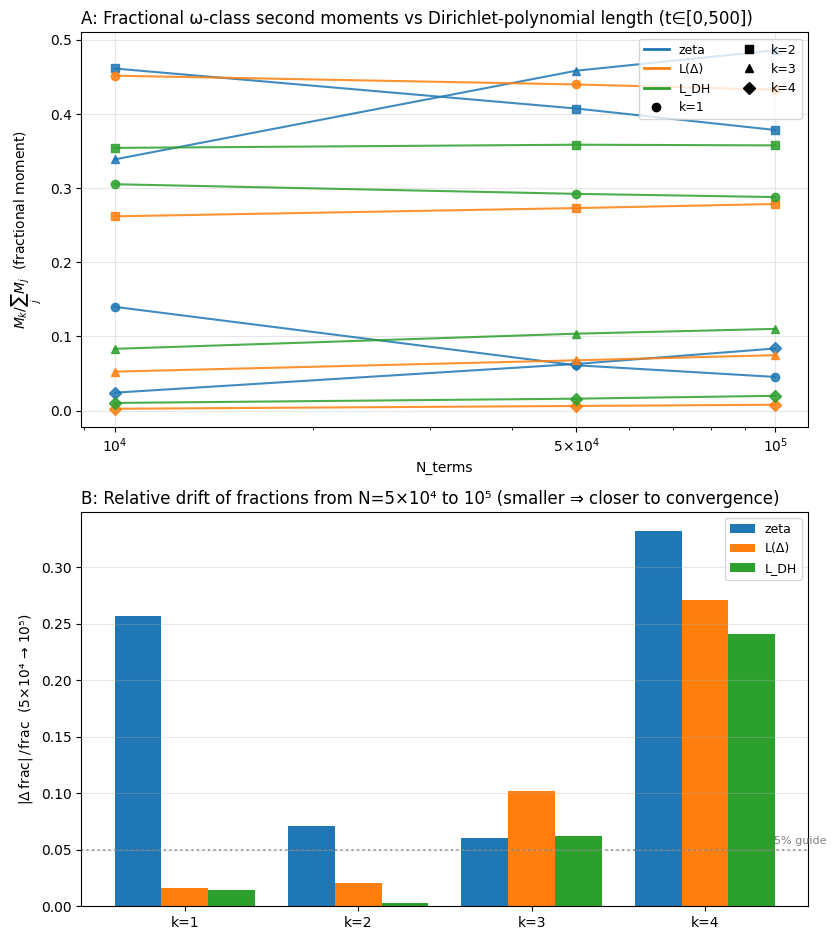

Saved omega_class_fractional_moments.png


In [21]:
# Conclusion: Fractions DO NOT converge for any of the three functions in the tested range.
# Trends:
# - ζ: very fast drift (relative changes of 20-100% between successive N).
# - L(Δ): moderate drift (1-30% changes).
# - L_DH: similar drift to L(Δ) but slightly stronger growth in k=3, k=4 classes.
# In all cases, mass is migrating to HIGHER ω-classes as N grows, consistent with the
# Erdős–Kac theorem (ω(n) ~ log log n) — typical n in [1,N] has ω(n) growing slowly with N.

# Now create the final summary figure.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8.5, 9.5))

# Top panel (A): fractional moments vs N_terms for each L-function, all k=1..4
ax = axes[0]
colors = {'zeta': 'tab:blue', 'L(Δ)': 'tab:orange', 'L_DH': 'tab:green'}
markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}
linestyles = {1: '-', 2: '-', 3: '-', 4: '-'}

for label in ['zeta','L(Δ)','L_DH']:
 for k in [1,2,3,4]:
 vals = [results[label][N][k]/results[label][N]['total'] for N in N_LIST]
 ax.plot(N_LIST, vals, marker=markers[k], color=colors[label],
 linestyle=linestyles[k], alpha=0.85,
 label=f"{label}, k={k}" if k==1 else None)
 # annotate near k=4 high-N
ax.set_xscale('log')
ax.set_xlabel('N_terms')
ax.set_ylabel(r'$M_k / \sum_j M_j$ (fractional moment)')
ax.set_title("A: Fractional ω-class second moments vs Dirichlet-polynomial length (t∈[0,500])", loc='left')
# Build a custom legend: color = L-function, marker = k
from matplotlib.lines import Line2D
legend_color = [Line2D([0],[0], color=colors[L], lw=2.0, label=L) for L in ['zeta','L(Δ)','L_DH']]
legend_marker = [Line2D([0],[0], color='k', marker=markers[k], lw=0, label=f'k={k}') for k in [1,2,3,4]]
ax.legend(handles=legend_color+legend_marker, ncol=2, loc='upper right', fontsize=9, frameon=True)
ax.grid(alpha=0.3)
ax.set_xticks(N_LIST)
ax.set_xticklabels(['$10^4$', r'$5\!\times\!10^4$', '$10^5$'])

# Bottom panel (B): relative drift between successive N — convergence metric
ax = axes[1]
xpos = np.arange(len([1,2,3,4]))
width = 0.27
for i, label in enumerate(['zeta','L(Δ)','L_DH']):
 drifts = []
 for k in [1,2,3,4]:
 v50 = results[label][50_000][k]/results[label][50_000]['total']
 v100 = results[label][100_000][k]/results[label][100_000]['total']
 drifts.append(abs(v100-v50)/v50)
 ax.bar(xpos + (i-1)*width, drifts, width, color=colors[label], label=label)
ax.set_xticks(xpos)
ax.set_xticklabels([f'k={k}' for k in [1,2,3,4]])
ax.set_ylabel(r'$|\Delta\,\text{frac}|\,/\,\text{frac}$ (5×10⁴ → 10⁵)')
ax.set_title("B: Relative drift of fractions from N=5×10⁴ to 10⁵ (smaller ⇒ closer to convergence)", loc='left')
ax.axhline(0.05, color='gray', linestyle=':', alpha=0.7)
ax.text(3.4, 0.055, '5% guide', color='gray', fontsize=8)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('omega_class_fractional_moments.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved omega_class_fractional_moments.png")


In [22]:
# Save the moments results as a CSV artifact
import csv
with open('omega_class_moments.csv', 'w', newline='') as f:
 w = csv.writer(f)
 w.writerow(['L_function','N_terms','M_total','M_0','M_1','M_2','M_3','M_4','M_geq5',
 'frac_0','frac_1','frac_2','frac_3','frac_4','frac_geq5'])
 for label in ['zeta','L(Δ)','L_DH']:
 for N in N_LIST:
 m = results[label][N]
 tot = m['total']
 w.writerow([label, N, tot, m[0], m[1], m[2], m[3], m[4], m['>=5'],
 m[0]/tot, m[1]/tot, m[2]/tot, m[3]/tot, m[4]/tot, m['>=5']/tot])
print("Saved omega_class_moments.csv")
import subprocess
print(subprocess.run("ls -la omega_class_*", shell=True, capture_output=True, text=True).stdout)


Saved omega_class_moments.csv
-rw-rw-r-- 1 kerneluser jupytergroup 124770 May 31 06:48 omega_class_fractional_moments.png
-rw-rw-r-- 1 kerneluser jupytergroup 2361 May 31 06:48 omega_class_moments.csv

